#### Dataset

In [1]:
# Name: news_data.csv, sample_news.txt
# Location: https://mitu.co.in/dataset

##### Download the dataset and save in your current working directory

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

#### Load the dataset

In [3]:
df = pd.read_csv('news_data.csv')

In [4]:
df.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [5]:
df.shape

(9900, 2)

In [6]:
df.columns

Index(['Text', 'label'], dtype='object')

#### Separate the input and output data

In [7]:
features = df['Text']  # input data 
labels = df['label']   # output data

In [8]:
features

0        Top Trump Surrogate BRUTALLY Stabs Him In The...
1       U.S. conservative leader optimistic of common ...
2       Trump proposes U.S. tax overhaul, stirs concer...
3        Court Forces Ohio To Allow Millions Of Illega...
4       Democrats say Trump agrees to work on immigrat...
                              ...                        
9895     Wikileaks Admits To Screwing Up IMMENSELY Wit...
9896    Trump consults Republican senators on Fed chie...
9897    Trump lawyers say judge lacks jurisdiction for...
9898     WATCH: Right-Wing Pastor Falsely Credits Trum...
9899     Sean Spicer HILARIOUSLY Branded As Chickensh*...
Name: Text, Length: 9900, dtype: object

In [9]:
labels

0       Fake
1       Real
2       Real
3       Fake
4       Real
        ... 
9895    Fake
9896    Real
9897    Real
9898    Fake
9899    Fake
Name: label, Length: 9900, dtype: object

In [10]:
set(labels)

{'Fake', 'Real'}

In [11]:
import seaborn as sns

<Axes: xlabel='label', ylabel='count'>

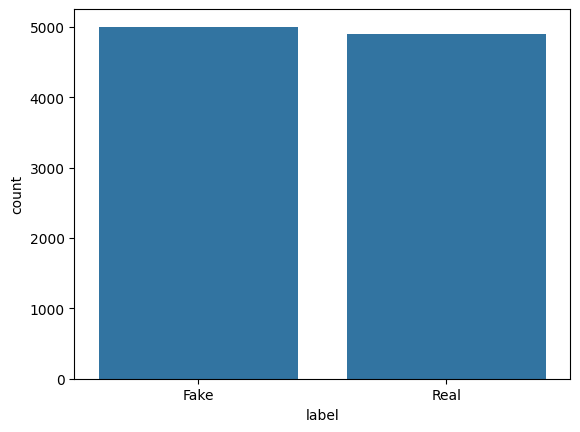

In [12]:
sns.countplot(x = labels)

In [13]:
labels.value_counts()

label
Fake    5000
Real    4900
Name: count, dtype: int64

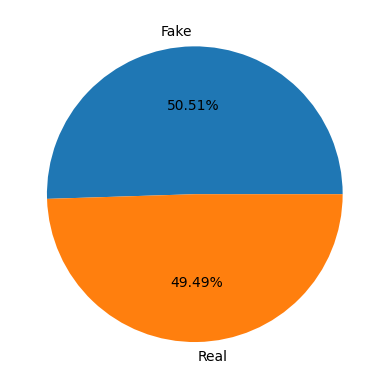

In [14]:
plt.pie(labels.value_counts(), 
        labels=labels.value_counts().index, autopct='%2.2f%%');

#### Data Preparation

##### Data Cleaning

In [15]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [16]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/aditya/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [17]:
sent = 'Hello friends! How are you? I like Python programming.'

In [18]:
tokens1 = word_tokenize(sent)
tokens1

['Hello',
 'friends',
 '!',
 'How',
 'are',
 'you',
 '?',
 'I',
 'like',
 'Python',
 'programming',
 '.']

In [19]:
# keep only the alphabets 
tokens2 = [x for x in tokens1 if x.isalpha()]

In [20]:
tokens2

['Hello', 'friends', 'How', 'are', 'you', 'I', 'like', 'Python', 'programming']

In [21]:
# remove stopwords 
swords = stopwords.words('english')

In [22]:
swords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [23]:
tokens3 = [x.lower() for x in tokens2 if x.lower() not in swords]

In [24]:
tokens3

['hello', 'friends', 'like', 'python', 'programming']

In [25]:
# apply the stemming
ps = PorterStemmer()

In [26]:
tokens4 = [ps.stem(x) for x in tokens3]

In [27]:
tokens4

['hello', 'friend', 'like', 'python', 'program']

In [28]:
def clean_text(sent):
    tokens1 = word_tokenize(sent)
    tokens2 = [x for x in tokens1 if x.isalpha()]
    tokens3 = [x.lower() for x in tokens2 if x.lower() not in swords]
    tokens4 = [ps.stem(x) for x in tokens3]
    return tokens4

In [29]:
sent

'Hello friends! How are you? I like Python programming.'

In [30]:
clean_text(sent)

['hello', 'friend', 'like', 'python', 'program']

In [31]:
new_sent = 'It was expected result. They told me the same on fields.'

In [32]:
clean_text(new_sent)

['expect', 'result', 'told', 'field']

In [33]:
clean_text(features[100])

['departur',
 'commun',
 'aid',
 'could',
 'first',
 'trump',
 'washington',
 'reuter',
 'presid',
 'donald',
 'trump',
 'commun',
 'director',
 'leav',
 'job',
 'white',
 'hous',
 'said',
 'tuesday',
 'presid',
 'consid',
 'wider',
 'staff',
 'chang',
 'tri',
 'contain',
 'polit',
 'damag',
 'investig',
 'russia',
 'presidenti',
 'campaign',
 'mike',
 'dubk',
 'confirm',
 'report',
 'resign',
 'say',
 'statement',
 'great',
 'honor',
 'serv',
 'presid',
 'trump',
 'dubk',
 'job',
 'three',
 'month',
 'gave',
 'reason',
 'leav',
 'trump',
 'return',
 'washington',
 'saturday',
 'trip',
 'middl',
 'east',
 'europ',
 'expect',
 'shake',
 'staff',
 'tackl',
 'firestorm',
 'investig',
 'alleg',
 'russian',
 'meddl',
 'presidenti',
 'elect',
 'commun',
 'russia',
 'trump',
 'campaign',
 'transit',
 'team',
 'trump',
 'plan',
 'bring',
 'new',
 'aid',
 'white',
 'hous',
 'ad',
 'experienc',
 'polit',
 'profession',
 'includ',
 'former',
 'campaign',
 'manag',
 'accord',
 'administr',
 'offic

##### TF*IDF Vectorization

In [34]:
# import the class 
from sklearn.feature_extraction.text import TfidfVectorizer

In [35]:
# create the object 
tfidf = TfidfVectorizer(analyzer=clean_text)

In [36]:
# apply the method 
features_new = tfidf.fit_transform(features)

In [37]:
features_new.shape

(9900, 33562)

In [38]:
tfidf.get_feature_names_out()

array(['aaa', 'aaaaackkk', 'aaaarrgh', ..., 'zzzzzzzzzzzzz', 'émigré',
       'ツ'], shape=(33562,), dtype=object)

In [39]:
len(tfidf.get_feature_names_out())

33562

In [40]:
features_new.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(9900, 33562))

#### Cross Validation

In [41]:
# import the function
from sklearn.model_selection import train_test_split

In [42]:
# split the data -> 75% in training and 25% in testing
x_train, x_test, y_train, y_test = train_test_split(
    features_new, labels, random_state=0
)

In [43]:
x_train.shape

(7425, 33562)

In [44]:
x_test.shape

(2475, 33562)

In [45]:
x_train[16]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 72 stored elements and shape (1, 33562)>

In [47]:
y_train[16]

'Fake'

#### Build the model

In [48]:
# import the model

from sklearn.tree import DecisionTreeClassifier

In [62]:
# create an object

dt = DecisionTreeClassifier(random_state= 0)

In [63]:
dt.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [64]:
# plot the tree

In [65]:
from sklearn.tree import plot_tree

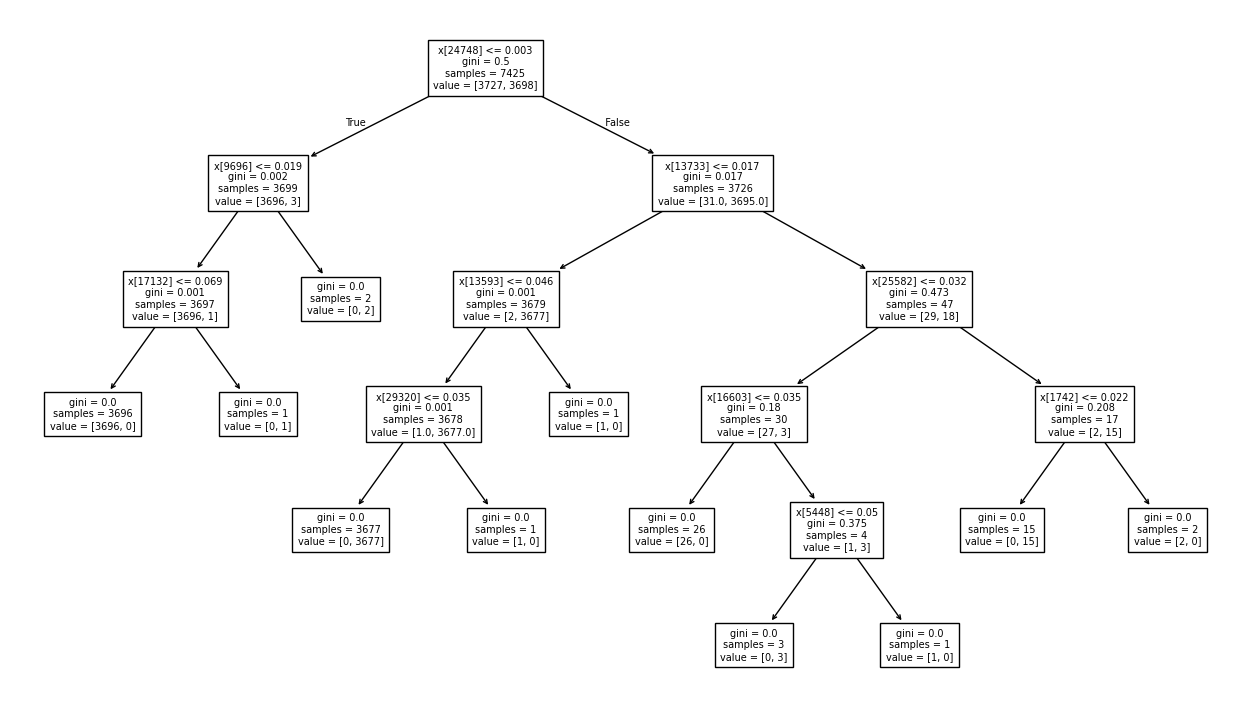

In [66]:
plt.figure(figsize=(16, 9))
plot_tree(dt, fontsize= 7);

## Evaluation

In [67]:
# predict on the test input

y_pred = dt.predict(x_test)

In [68]:
y_pred

array(['Fake', 'Fake', 'Fake', ..., 'Fake', 'Fake', 'Fake'],
      shape=(2475,), dtype=object)

In [69]:
y_pred.shape

(2475,)

In [70]:
# confusion matrix

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay

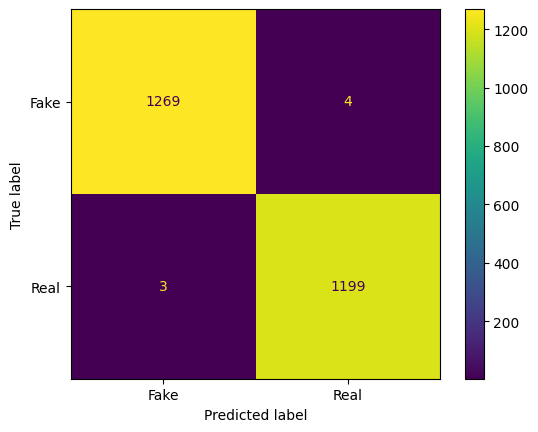

In [72]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

In [73]:
# classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      1273
        Real       1.00      1.00      1.00      1202

    accuracy                           1.00      2475
   macro avg       1.00      1.00      1.00      2475
weighted avg       1.00      1.00      1.00      2475



In [74]:
recall = 1269/1273

prec =  1269/1272 

In [75]:
recall, prec

(0.9968578161822467, 0.9976415094339622)

In [76]:
# overall accuracy

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9971717171717172

## prediction on unseen new news

In [79]:
# data -> sample_news.txt (encoding -> utf-8)

In [80]:
f = open('sample_news.txt', encoding = 'utf-8')

In [81]:
news = f.readlines()

In [82]:
news

['" Donald Trump’s ‘Charity’ Foundation Is About To Be Shut The F**k Down NATIONWIDE Things really aren t looking too great for Donald Trump s charity foundation. With recent developments prohibiting the Trump Foundation from soliciting funds in New York state, it s now looking like a good majority of states may be following suit.The Trump Foundation has also been being looked at by the Attorney General for how it is getting and spending funds, especially after what happen with veterans organizations earlier this year.According to The Daily Beast: To make matters worse for the Trump Foundation, the probe may not be limited to New York: Charity experts and lawyers tell The Daily Beast that the attorneys general of other states may soon get involved in a long, drawn-out process.All major charities are required to register with 41 different states across the nation in order to individually request permission to fundraise. When Trump raised money for veterans, he may have broken the rules 

In [83]:
# prediction

dt.predict(tfidf.transform(news))

array(['Fake', 'Real', 'Fake'], dtype=object)